# Earnings Event Volatility: Options Implied Moves vs. Realized Reactions

**Author:** Ryan Varga

## Objective

Before an earnings release, the price of the at-the-money straddle tells us how large a move the options market expects. This project asks a simple question: **did the options market correctly price the most recent earnings reaction for ten AI, semiconductor, and power names?**

The analysis has four parts:

1. Measure each stock's realized earnings reaction, adjusted for the market's move that day (a market-adjusted event study).
2. Compare the realized reaction with the options implied move.
3. Use Monte Carlo simulation to test whether the gap between realized and implied moves is statistically meaningful or consistent with fair pricing.
4. Extend the historical record for each name to 12 quarters using live data (Part 2, run locally).

**Sample:** CEG, AMD, META, MU, NVDA, MSFT, VST, AMZN, AMAT, GEV, using each company's most recent completed earnings release as of September 2026.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, t
from scipy.special import gamma

pd.set_option("display.width", 160)
pd.set_option("display.precision", 2)

## 1. Event data

**Timing matters.** For a release after the close (AMC), the reaction is the report day's close to the next day's close. For a release before the open (BMO), it is the prior day's close to the report day's close.

**Implied moves** come from Barchart's weekly *Option Volatility and Earnings Report*, which quotes the at-the-money straddle for the nearest expiration as a percent of the stock price. Using one source keeps the methodology consistent. Micron reported in a week not covered by that series, so its figure comes from Saxo's straddle-based preview; other outlets quoted 12.9% (TipRanks) and 14% (Benzinga) for the same event, which shows how sensitive implied moves are to methodology and timing. No published implied move was found for CEG, so it is included for its realized reaction only.

**Closing prices** come from Yahoo Finance historical data. Verify every figure before relying on it.

In [2]:
BARCHART = "Barchart, Option Volatility and Earnings Report (weekly)"
events = pd.DataFrame([
    # ticker, report date, timing, pre close, post close, SPY pre, SPY post, implied move %, implied move source
    ("MU",   "2026-06-24", "AMC", 1048.51, 1213.56, 733.24, 734.30, 11.03, "Saxo, June 23, 2026 preview"),
    ("NVDA", "2026-08-26", "AMC",  209.66,  227.98, 766.08, 771.10,  6.10, BARCHART),
    ("MSFT", "2026-07-29", "AMC",  390.54,  451.10, 729.46, 741.69,  7.20, BARCHART),
    ("META", "2026-07-29", "AMC",  585.61,  539.03, 729.46, 741.69,  8.40, BARCHART),
    ("AMZN", "2026-07-30", "AMC",  235.50,  271.58, 741.69, 747.03,  7.20, BARCHART),
    ("AMD",  "2026-08-04", "AMC",  518.58,  482.05, 771.33, 769.79,  9.90, BARCHART),
    ("AMAT", "2026-08-13", "AMC",  534.54,  507.18, 777.88, 776.34,  9.60, BARCHART),
    ("GEV",  "2026-07-22", "BMO", 1078.81,  985.03, 748.28, 747.41,  8.60, BARCHART),
    ("VST",  "2026-08-07", "BMO",  141.38,  140.59, 768.56, 773.26,  7.90, BARCHART),
    ("CEG",  "2026-08-06", "BMO",  265.12,  261.10, 769.79, 768.56, np.nan, "Not found"),
], columns=["ticker", "date", "timing", "pre", "post", "spy_pre", "spy_post", "implied", "implied_source"])

events["sector"] = events.ticker.map({
    "MU": "Semiconductors", "NVDA": "Semiconductors", "AMD": "Semiconductors", "AMAT": "Semiconductors",
    "MSFT": "Hyperscalers", "META": "Hyperscalers", "AMZN": "Hyperscalers",
    "GEV": "Power & Infrastructure", "VST": "Power & Infrastructure", "CEG": "Power & Infrastructure",
})
events[["ticker", "sector", "date", "timing", "implied", "implied_source"]]

,ticker,sector,date,timing,implied,implied_source
0,MU,Semiconductors,2026-06-24,AMC,11.03,"Saxo, June 23, 2026 preview"
1,NVDA,Semiconductors,2026-08-26,AMC,6.10,"Barchart, Option Volatility and Earnings Repor..."
2,MSFT,Hyperscalers,2026-07-29,AMC,7.20,"Barchart, Option Volatility and Earnings Repor..."
3,META,Hyperscalers,2026-07-29,AMC,8.40,"Barchart, Option Volatility and Earnings Repor..."
4,AMZN,Hyperscalers,2026-07-30,AMC,7.20,"Barchart, Option Volatility and Earnings Repor..."
5,AMD,Semiconductors,2026-08-04,AMC,9.90,"Barchart, Option Volatility and Earnings Repor..."
6,AMAT,Semiconductors,2026-08-13,AMC,9.60,"Barchart, Option Volatility and Earnings Repor..."
7,GEV,Power & Infrastructure,2026-07-22,BMO,8.60,"Barchart, Option Volatility and Earnings Repor..."
8,VST,Power & Infrastructure,2026-08-07,BMO,7.90,"Barchart, Option Volatility and Earnings Repor..."
9,CEG,Power & Infrastructure,2026-08-06,BMO,NaN,Not found


## 2. Realized vs. implied moves

The **abnormal return** removes the market's move that day (stock return minus SPY return). This is the same market-adjusted approach used in event studies; Part 2 upgrades it to a full market model with an estimated beta.

Two comparison metrics:

* **Realized / implied ratio:** above 1.0 means the stock moved more than the options market priced.
* **Long straddle proxy (points):** the absolute abnormal move minus the implied move. Positive values mean an at-the-money straddle bought before the release would have roughly paid off, ignoring bid-ask spreads and the value left in the options after the event.

In [3]:
df = events.copy()
df["raw_move"] = 100 * (df.post / df.pre - 1)
df["spy_move"] = 100 * (df.spy_post / df.spy_pre - 1)
df["abnormal"] = df.raw_move - df.spy_move
df["abs_abnormal"] = df.abnormal.abs()
df["ratio"] = df.abs_abnormal / df.implied
df["straddle_pts"] = df.abs_abnormal - df.implied

df[["ticker", "sector", "raw_move", "spy_move", "abnormal", "implied", "ratio", "straddle_pts"]]

,ticker,sector,raw_move,spy_move,abnormal,implied,ratio,straddle_pts
0,MU,Semiconductors,15.74,0.14,15.60,11.03,1.41,4.57
1,NVDA,Semiconductors,8.74,0.66,8.08,6.10,1.33,1.98
2,MSFT,Hyperscalers,15.51,1.68,13.83,7.20,1.92,6.63
3,META,Hyperscalers,-7.95,1.68,-9.63,8.40,1.15,1.23
4,AMZN,Hyperscalers,15.32,0.72,14.60,7.20,2.03,7.40
5,AMD,Semiconductors,-7.04,-0.20,-6.84,9.90,0.69,-3.06
6,AMAT,Semiconductors,-5.12,-0.20,-4.92,9.60,0.51,-4.68
7,GEV,Power & Infrastructure,-8.69,-0.12,-8.58,8.60,1.00,-0.02
8,VST,Power & Infrastructure,-0.56,0.61,-1.17,7.90,0.15,-6.73
9,CEG,Power & Infrastructure,-1.52,-0.16,-1.36,NaN,NaN,NaN


In [4]:
s = df.dropna(subset=["implied"])
print(f"Events with an implied move:        {len(s)}")
print(f"Moved more than implied:            {(s.ratio > 1).sum()} of {len(s)}")
print(f"Average implied move:               {s.implied.mean():.2f}%")
print(f"Average absolute abnormal move:     {s.abs_abnormal.mean():.2f}%")
print(f"Mean realized / implied ratio:      {s.ratio.mean():.2f}")
print(f"Median realized / implied ratio:    {s.ratio.median():.2f}")
print(f"Average long straddle proxy:        {s.straddle_pts.mean():+.2f} pts")
print()
print(s.groupby("sector")[["implied", "abs_abnormal", "ratio"]].mean())

Events with an implied move:        9
Moved more than implied:            5 of 9
Average implied move:               8.44%
Average absolute abnormal move:     9.25%
Mean realized / implied ratio:      1.13
Median realized / implied ratio:    1.15
Average long straddle proxy:        +0.81 pts

                        implied  abs_abnormal  ratio
sector                                              
Hyperscalers               7.60         12.69   1.70
Power & Infrastructure     8.25          4.87   0.57
Semiconductors             9.16          8.86   0.99


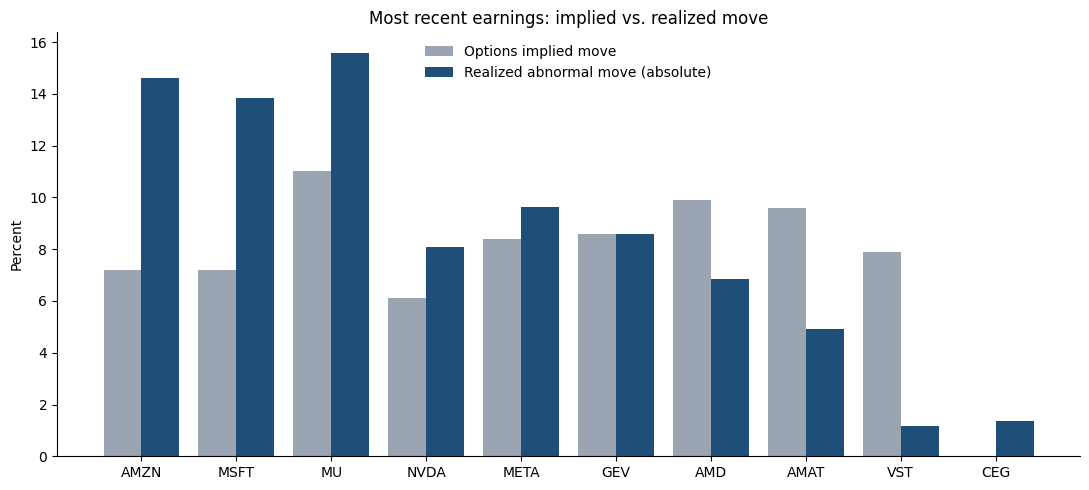

In [5]:
order = df.sort_values("ratio", ascending=False, na_position="last")
x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - 0.2, order.implied, 0.4, label="Options implied move", color="#9aa5b1")
ax.bar(x + 0.2, order.abs_abnormal, 0.4, label="Realized abnormal move (absolute)", color="#1f4e79")
ax.set_xticks(x, order.ticker)
ax.set_ylabel("Percent")
ax.set_title("Most recent earnings: implied vs. realized move")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Monte Carlo: is the gap meaningful?

Five of nine stocks moved more than implied, and the average ratio is above 1.0. The question a trader would ask is whether that is evidence the options market underpriced these events, or just what randomness looks like in a small sample.

**Method.** If the market prices the earnings move correctly, the straddle price equals the expected absolute move. Under a normal earnings jump with standard deviation $\sigma$, the expected absolute move is $\sigma\sqrt{2/\pi}$, so each implied move converts to

$$\sigma_{\text{jump}} = \frac{\text{implied move}}{\sqrt{2/\pi}}$$

We then simulate 200,000 alternate earnings seasons for all nine names at once (with antithetic variates to reduce variance), assuming the market was exactly right, and count how often the simulated average ratio is at least as large as the one observed.

Earnings reactions have fatter tails than a normal distribution, so the test is repeated with a Student's t jump (3 degrees of freedom) scaled to the same expected absolute move.

In [6]:
rng = np.random.default_rng(2026)
N_SIMS = 200_000

implied = s.implied.to_numpy()
observed_ratio = s.ratio.mean()
observed_exceed = int((s.ratio > 1).sum())

# Normal jumps, calibrated so E|move| equals the implied move
sigma_jump = implied / np.sqrt(2 / np.pi)
Z = rng.standard_normal((N_SIMS // 2, len(implied)))
Z = np.vstack([Z, -Z])                      # antithetic variates
sim_normal = np.abs(Z * sigma_jump)

# Student's t jumps (nu = 3), scaled to the same expected absolute move
nu = 3
mean_abs_t = 2 * np.sqrt(nu) * gamma((nu + 1) / 2) / (np.sqrt(np.pi) * (nu - 1) * gamma(nu / 2))
sim_t = np.abs(t.rvs(nu, size=(N_SIMS, len(implied)), random_state=7) * implied / mean_abs_t)

for name, sims in [("Normal jumps", sim_normal), ("Student's t jumps", sim_t)]:
    ratios = (sims / implied).mean(axis=1)
    exceed = (sims > implied).sum(axis=1)
    print(name)
    print(f"  Mean simulated ratio (should be ~1.00):         {ratios.mean():.3f}")
    print(f"  P(avg ratio >= {observed_ratio:.2f} | fair pricing):        {(ratios >= observed_ratio).mean():.3f}")
    print(f"  P(>= {observed_exceed} of 9 beat implied | fair pricing):     {(exceed >= observed_exceed).mean():.3f}")
    print()

Normal jumps
  Mean simulated ratio (should be ~1.00):         0.999
  P(avg ratio >= 1.13 | fair pricing):        0.288
  P(>= 5 of 9 beat implied | fair pricing):     0.320

Student's t jumps
  Mean simulated ratio (should be ~1.00):         1.000
  P(avg ratio >= 1.13 | fair pricing):        0.287
  P(>= 5 of 9 beat implied | fair pricing):     0.174



In [7]:
# Per-name probability of a move at least as large as the realized one, under the market's own pricing.
# The Monte Carlo estimate should match the closed-form normal probability, which validates the simulation.
s = s.assign(
    sigma_jump=sigma_jump,
    p_mc=(sim_normal >= s.abs_abnormal.to_numpy()).mean(axis=0),
    p_closed_form=2 * (1 - norm.cdf(s.abs_abnormal / sigma_jump)),
)
s[["ticker", "implied", "abs_abnormal", "sigma_jump", "p_mc", "p_closed_form"]].sort_values("p_mc")

,ticker,implied,abs_abnormal,sigma_jump,p_mc,p_closed_form
4,AMZN,7.20,14.60,9.02,0.10,0.11
2,MSFT,7.20,13.83,9.02,0.13,0.13
0,MU,11.03,15.60,13.82,0.26,0.26
1,NVDA,6.10,8.08,7.65,0.29,0.29
3,META,8.40,9.63,10.53,0.36,0.36
7,GEV,8.60,8.58,10.78,0.43,0.43
5,AMD,9.90,6.84,12.41,0.58,0.58
6,AMAT,9.60,4.92,12.03,0.68,0.68
8,VST,7.90,1.17,9.90,0.91,0.91


## 4. Model check: Monte Carlo straddle pricing with an earnings jump

To connect the implied move back to option prices, this function prices an at-the-money straddle on a stock that follows geometric Brownian motion plus a single earnings jump. With the jump set to zero it must reproduce Black-Scholes, which is the validation test below. With a jump, the straddle is worth more, and for a short-dated option most of its value comes from the earnings event.

In [8]:
def black_scholes(S, K, r, sigma, T, kind):
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if kind == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


def mc_earnings_straddle(S, K, r, sigma, T, jump_sigma, n_paths=400_000, seed=11):
    """Straddle price under GBM plus one lognormal earnings jump, using antithetic variates."""
    rng = np.random.default_rng(seed)
    z = rng.standard_normal(n_paths // 2); z = np.concatenate([z, -z])
    j = rng.standard_normal(n_paths // 2); j = np.concatenate([j, -j])
    diffusion = (r - sigma**2 / 2) * T + sigma * np.sqrt(T) * z
    jump = jump_sigma * j - jump_sigma**2 / 2          # mean-zero jump keeps the price risk-neutral
    ST = S * np.exp(diffusion + jump)
    payoff = np.exp(-r * T) * np.abs(ST - K)
    return payoff.mean(), 1.96 * payoff.std(ddof=1) / np.sqrt(n_paths)

S, K, r, sigma, T = 100, 100, 0.04, 0.35, 7 / 365

bs = black_scholes(S, K, r, sigma, T, "call") + black_scholes(S, K, r, sigma, T, "put")
mc, ci = mc_earnings_straddle(S, K, r, sigma, T, jump_sigma=0.0)
print(f"No jump:  MC straddle {mc:.3f} +/- {ci:.3f}   Black-Scholes {bs:.3f}")

mc_j, ci_j = mc_earnings_straddle(S, K, r, sigma, T, jump_sigma=0.09)
print(f"9% jump:  MC straddle {mc_j:.3f} +/- {ci_j:.3f}   ({mc_j / S:.1%} of spot, vs {bs / S:.1%} without the event)")

No jump:  MC straddle 3.863 +/- 0.009   Black-Scholes 3.866
9% jump:  MC straddle 8.119 +/- 0.019   (8.1% of spot, vs 3.9% without the event)


## 5. Part 2 (run locally): 12 quarters of earnings history

The cells above use one event per stock. This section pulls each company's last 12 earnings dates and daily prices with `yfinance`, estimates beta over a 250-day window ending 10 trading days before each event, and computes market-model abnormal returns. That produces each stock's historical average earnings move, which can be compared with the implied move to judge whether options were rich or cheap relative to history.

Set `RUN_LIVE = True` and run on a machine with internet access (`pip install yfinance`). Earnings timestamps from Yahoo can be wrong, so spot-check the dates.

In [9]:
RUN_LIVE = False
TICKERS = ["CEG", "AMD", "META", "MU", "NVDA", "MSFT", "VST", "AMZN", "AMAT", "GEV"]

def earnings_history(ticker, n_events=12, est_window=250, gap=10):
    import yfinance as yf
    px = yf.download([ticker, "SPY"], period="5y", auto_adjust=True, progress=False)["Close"].dropna()
    rets = px.pct_change().dropna()
    dates = yf.Ticker(ticker).get_earnings_dates(limit=n_events + 8)
    dates = dates[dates.index < pd.Timestamp.now(tz=dates.index.tz)].head(n_events)
    out = []
    for ts in dates.index:
        day = pd.Timestamp(ts.date())
        # after-close releases react on the next session; before-open releases react the same day
        loc = rets.index.searchsorted(day) + (1 if ts.hour >= 16 else 0)
        if loc >= len(rets) or loc - gap - est_window < 0:
            continue
        est = rets.iloc[loc - gap - est_window: loc - gap]
        beta, alpha = np.polyfit(est["SPY"], est[ticker], 1)
        event = rets.iloc[loc]
        abnormal = event[ticker] - (alpha + beta * event["SPY"])
        out.append({"ticker": ticker, "reaction_date": rets.index[loc].date(),
                    "raw_move": 100 * event[ticker], "beta": beta, "abnormal": 100 * abnormal})
    return pd.DataFrame(out)

if RUN_LIVE:
    hist = pd.concat([earnings_history(tk) for tk in TICKERS], ignore_index=True)
    summary = (hist.assign(abs_abnormal=hist.abnormal.abs())
                   .groupby("ticker")
                   .agg(events=("abnormal", "size"), avg_abs_move=("abs_abnormal", "mean"),
                        median_abs_move=("abs_abnormal", "median"), avg_beta=("beta", "mean")))
    summary = summary.join(events.set_index("ticker")["implied"])
    summary["implied_vs_history"] = summary.implied / summary.avg_abs_move
    display(summary.sort_values("implied_vs_history"))
else:
    print("Set RUN_LIVE = True to pull 12 quarters of history with yfinance.")

Set RUN_LIVE = True to pull 12 quarters of history with yfinance.


## 6. Findings

1. **The options market was roughly right on average, but not name by name.** Five of nine stocks moved more than implied, and the average realized move was about 1.1 times the implied move. The average long straddle would have earned less than one point before trading costs.
2. **The gap is not statistically meaningful.** If the market had priced every event correctly, a result at least this large would occur in about 29% of simulated earnings seasons under both normal and fat-tailed jump assumptions. Nine events cannot show that options were systematically cheap.
3. **Reactions split by business model.** The hyperscalers (MSFT, AMZN, META) and the memory and GPU names (MU, NVDA) moved more than priced, with MSFT and AMZN each moving roughly twice their implied move. VST, AMAT, and AMD moved well less than priced, and GEV moved almost exactly its implied move. With one event per name, this split is an observation to test with more quarters, not a conclusion.
4. **Tail events still happen within fair pricing.** MSFT's and AMZN's moves had about a 1 in 8 and 1 in 10 probability under the market's own pricing, which is unusual but not extreme.

**Limitations.** One event per stock, implied moves taken from published sources rather than historical option chains, a market-adjusted return rather than a full market model in Part 1, and a straddle proxy that ignores spreads and residual option value after the event. Part 2 addresses the sample size by extending each name to 12 quarters.